In [51]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt

In [1]:

names = ["Rahul","Priya","Amit","Sneha","Rohan","Kiran","Anjali","Vikas"]
cities = ["Bangalore","Mumbai","Delhi","Chennai","Pune"]
courses = ["Python","Data Science","ML","AI"]

data = {
    "Student_ID": range(1,1001),
    "Name": np.random.choice(names,1000),
    "Age": np.random.randint(18,30,1000),
    "Course": np.random.choice(courses,1000),
    "Marks": np.random.randint(40,101,1000),
    "Attendance": np.random.randint(50,101,1000),
    "City": np.random.choice(cities,1000)
}

df = pd.DataFrame(data)

# Make dirty data
df.loc[10,"Marks"] = np.nan
df.loc[20,"Attendance"] = np.nan
df.loc[30,"Age"] = -5
df.loc[40,"Marks"] = 150
df.loc[50,"Attendance"] = 120

# Duplicate rows
df = pd.concat([df, df.iloc[:10]])

df.to_csv("students_dirty.csv", index=False)

print("CSV Created")

CSV Created


### View Data

In [7]:
df=pd.read_csv("students_dirty.csv")
df.head()

,Student_ID,Name,Age,Course,Marks,Attendance,City
0,1,Priya,27,AI,80.0,63.0,Bangalore
1,2,Rahul,21,Data Science,65.0,95.0,Mumbai
2,3,Vikas,18,Data Science,79.0,83.0,Bangalore
3,4,Kiran,26,AI,80.0,97.0,Bangalore
4,5,Rahul,29,Data Science,52.0,91.0,Pune


In [8]:
df.tail()

,Student_ID,Name,Age,Course,Marks,Attendance,City
1005,6,Anjali,23,AI,50.0,77.0,Pune
1006,7,Priya,25,ML,84.0,78.0,Bangalore
1007,8,Rahul,27,Python,48.0,84.0,Pune
1008,9,Priya,23,Python,51.0,65.0,Pune
1009,10,Sneha,28,Data Science,72.0,55.0,Pune


In [11]:
df.sample(3)

,Student_ID,Name,Age,Course,Marks,Attendance,City
735,736,Priya,21,ML,50.0,87.0,Mumbai
520,521,Rahul,23,Data Science,60.0,64.0,Pune
23,24,Sneha,29,ML,80.0,94.0,Pune


### Dataset Information

In [17]:
df.shape

(1010, 7)

In [13]:
df.dtypes

Student_ID      int64
Name           object
Age             int64
Course         object
Marks         float64
Attendance    float64
City           object
dtype: object

In [14]:
df.columns

Index(['Student_ID', 'Name', 'Age', 'Course', 'Marks', 'Attendance', 'City'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  1010 non-null   int64  
 1   Name        1010 non-null   object 
 2   Age         1010 non-null   int64  
 3   Course      1010 non-null   object 
 4   Marks       1009 non-null   float64
 5   Attendance  1009 non-null   float64
 6   City        1010 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 55.4+ KB


### Basic Statistics

In [16]:
df.describe()

,Student_ID,Age,Marks,Attendance
count,1010.000000,1010.000000,1009.000000,1009.000000
mean,495.599010,23.388119,70.093162,74.850347
std,291.537945,3.644491,17.666982,14.904471
min,1.000000,-5.000000,40.000000,50.000000
25%,243.250000,20.000000,55.000000,62.000000
50%,495.500000,23.000000,71.000000,75.000000
75%,747.750000,27.000000,85.000000,88.000000
max,1000.000000,29.000000,150.000000,120.000000


In [20]:
df['Marks'].mean().round(2)

np.float64(70.09)

In [21]:
df['Marks'].max()

150.0

In [22]:
df['Marks'].min()

40.0

### Missing And Duplicates

In [24]:
df.isnull()

,Student_ID,Name,Age,Course,Marks,Attendance,City
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1005,False,False,False,False,False,False,False
1006,False,False,False,False,False,False,False
1007,False,False,False,False,False,False,False
1008,False,False,False,False,False,False,False


In [23]:
df.isnull().sum()

Student_ID    0
Name          0
Age           0
Course        0
Marks         1
Attendance    1
City          0
dtype: int64

In [25]:
df.fillna(0)

,Student_ID,Name,Age,Course,Marks,Attendance,City
0,1,Priya,27,AI,80.0,63.0,Bangalore
1,2,Rahul,21,Data Science,65.0,95.0,Mumbai
2,3,Vikas,18,Data Science,79.0,83.0,Bangalore
3,4,Kiran,26,AI,80.0,97.0,Bangalore
4,5,Rahul,29,Data Science,52.0,91.0,Pune
...,...,...,...,...,...,...,...
1005,6,Anjali,23,AI,50.0,77.0,Pune
1006,7,Priya,25,ML,84.0,78.0,Bangalore
1007,8,Rahul,27,Python,48.0,84.0,Pune
1008,9,Priya,23,Python,51.0,65.0,Pune


In [27]:
df.duplicated().sum()

np.int64(10)

In [28]:
df.drop_duplicates()

,Student_ID,Name,Age,Course,Marks,Attendance,City
0,1,Priya,27,AI,80.0,63.0,Bangalore
1,2,Rahul,21,Data Science,65.0,95.0,Mumbai
2,3,Vikas,18,Data Science,79.0,83.0,Bangalore
3,4,Kiran,26,AI,80.0,97.0,Bangalore
4,5,Rahul,29,Data Science,52.0,91.0,Pune
...,...,...,...,...,...,...,...
995,996,Rohan,29,AI,58.0,87.0,Delhi
996,997,Anjali,28,ML,71.0,68.0,Chennai
997,998,Anjali,29,ML,79.0,81.0,Mumbai
998,999,Rohan,19,Data Science,70.0,54.0,Mumbai


### Find Wrong Values

In [29]:
df[df["Age"] < 0]

,Student_ID,Name,Age,Course,Marks,Attendance,City
30,31,Amit,-5,AI,71.0,94.0,Chennai


In [30]:
df[df["Marks"] > 100]

,Student_ID,Name,Age,Course,Marks,Attendance,City
40,41,Rahul,19,Data Science,150.0,96.0,Bangalore


In [31]:
df[df["Attendance"] > 100]

,Student_ID,Name,Age,Course,Marks,Attendance,City
50,51,Amit,25,AI,48.0,120.0,Pune


In [37]:
df.loc[df["Age"] < 0, "Age"] = np.nan

df.loc[df["Marks"] > 100, "Marks"] = np.nan

df.loc[df["Attendance"] > 100, "Attendance"] = np.nan

In [39]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Marks"] = df["Marks"].fillna(df["Marks"].mean())

df["Attendance"] = df["Attendance"].fillna(
    df["Attendance"].mean()
)

### Formating

In [45]:
df["Name"] = df["Name"].str.strip()
df["Course"] = df["Course"].str.strip()
df["City"] = df["City"].str.strip()

### Analysis

In [47]:
df["City"].value_counts() # Student Count By City

City
Pune         212
Chennai      209
Bangalore    203
Mumbai       194
Delhi        192
Name: count, dtype: int64

In [48]:
df["Course"].value_counts()  # Student Count By Course

Course
Python          282
ML              255
Data Science    237
AI              236
Name: count, dtype: int64

In [49]:
df.groupby("City")["Student_ID"].count() 

City
Bangalore    203
Chennai      209
Delhi        192
Mumbai       194
Pune         212
Name: Student_ID, dtype: int64

### Visualization

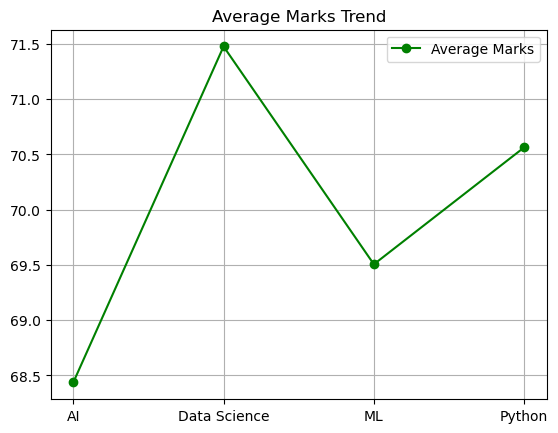

In [67]:
course_avg = df.groupby("Course")["Marks"].mean()

plt.plot(
    course_avg.index,
    course_avg.values,
    marker="o",
    color="green",
    label="Average Marks"
)

plt.title("Average Marks Trend")
plt.legend()
plt.grid(True)


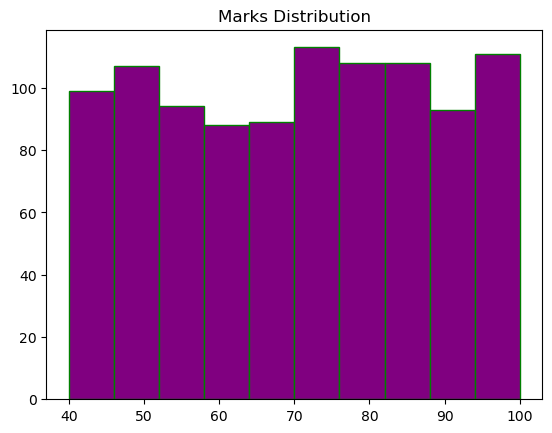

In [53]:
plt.hist(df["Marks"], bins=10,color='purple',edgecolor='green')
plt.title("Marks Distribution")
plt.show()

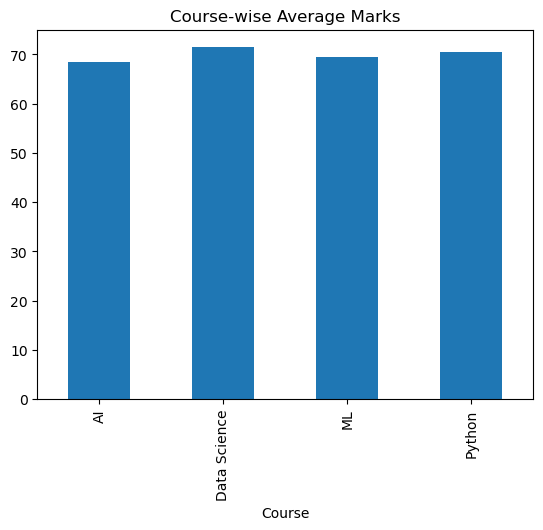

In [57]:
df.groupby("Course")["Marks"].mean().plot(kind="bar")

plt.title("Course-wise Average Marks")
plt.show()

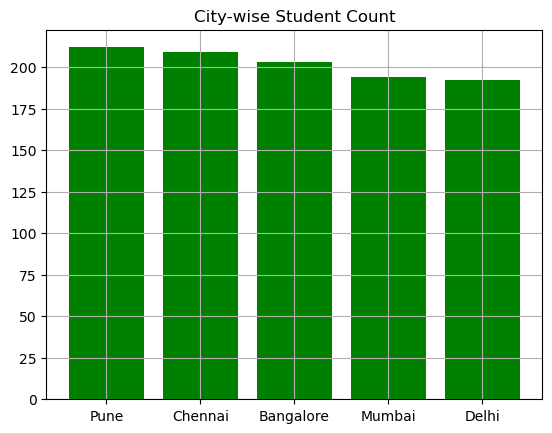

In [60]:
city_count = df["City"].value_counts()

plt.bar(
    city_count.index,
    city_count.values,
    color="green"
)

plt.title("City-wise Student Count")
plt.grid(True)


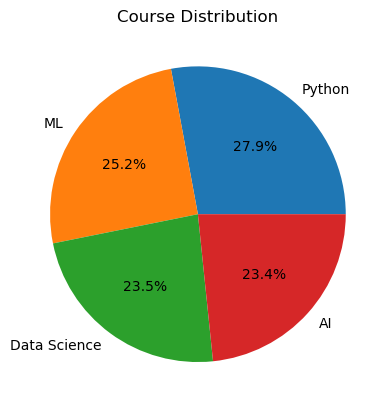

In [74]:
course_count = df["Course"].value_counts()

plt.pie(
    course_count,
    labels=course_count.index,
    autopct="%1.1f%%"
)

plt.title("Course Distribution")

plt.show()

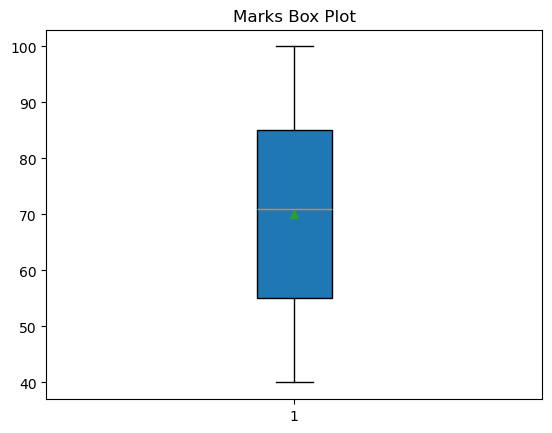

In [83]:
plt.boxplot(
    df["Marks"],
    patch_artist=True,
    showmeans=True,
   showfliers=True
)

plt.title("Marks Box Plot")

plt.show()